# Benford's Law — do stock prices really obey it, and can the deviation flag trouble? 🔢
### A forensic-accounting trick, pointed at the market, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_forensic_red--flag%3F: Not_supported](https://img.shields.io/badge/A_forensic_red--flag%3F-Not_supported-8b949e?style=flat-square)

There's a famous bit of number-magic called **Benford's Law**: in many real-world datasets the first digit is a **1** about 30% of the time, a **9** less than 5% — not the flat ~11% each you'd guess. Auditors use it to catch faked numbers. The viral trading version says: *if a stock's prices stray from Benford's Law, something's wrong — and you can trade the deviation.* This notebook checks whether prices obey the law at all, and whether the deviation is worth a dime.

> **This is the plain-language layer.** Want the χ² tests, the survivorship confound and the HAC *t*-stats? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from benford_law import data, strategy as st

def have_real(ticker="SPY"):
    return data.cache_available(ticker)

HAVE_REAL = have_real()
print("real price cache present:", HAVE_REAL)


real price cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Do *prices* obey Benford's Law? | **A single stock's prices — no.** SPY's first-digit deviation (MAD **0.042**) is way past the 'nonconformity' line (0.015) — because SPY only ranged ~1.2 decades and sat in the 400s for years. |
| Then what *does* obey it? | **Returns.** A day's % move spans tiny to huge, so its leading digit is beautifully Benford (SPY abs-returns MAD **0.009**). The folklore points at the wrong column. |
| Does a 'deviation' flag trouble? | **No.** A high price-deviation just means the price lived in a *narrow range* — that's geometry, not fraud or weakness. |
| Can you trade the deviation? | **No.** The only place a deviation-sort looks profitable (*t* ≈ +3.6) is a **survivorship-biased** list of today's winners — a universe you couldn't have known in advance. |

> Benford's Law is a real tool — for *auditing reported figures*. Stretched into a price-trading signal it measures the width of a price range and the luck of survival, and calls it 'integrity.'

## 1 · The claim

> *"Stock prices, like most natural data, follow Benford's Law. When a stock's prices **deviate** from the expected first-digit distribution, it's a red flag — a sign of manipulation or instability. Screen for high-deviation names and avoid (or short) them."*

— the popular forensic-trading framing (descended from Nigrini's audit work and Ley's 1996 finding that the S&P 500 *index* digits broadly conform)

The respectable core is real: Benford's Law genuinely catches fabricated accounting numbers, and the **index over a century** does conform. The leap under test is whether an **individual security's price** conforms, whether a *deviation* means trouble, and whether you can *trade* it.

## 2 · So what?

If it worked, you'd have a free fraud-and-fragility detector: rank the market by a first-digit score, dodge the dodgy names, pocket the difference. It would also be a deep statement — that price *integrity* leaves a fingerprint in the digits. But Benford's Law has a precondition that's easy to forget: it only holds for numbers that **span several orders of magnitude on a log scale.** Whether a stock price meets that bar — and what a 'deviation' therefore *means* — is the whole game.

## 3 · How would we even know?

Three checks:

1. **Does the law even hold?** Take real prices, count the leading digits, compare to Benford. Do the same for *returns*. (We build two synthetic tapes first — one we *know* should conform, one we *know* shouldn't — to prove our measuring stick works.)
2. **What does a deviation track?** Correlate a name's deviation with its price *range* and its recent *return* — is it integrity, or just geometry?
3. **Can you trade it?** Every month, short the most-deviant names and long the most-conforming, and measure the spread honestly — then ask what survives once you remember the list of names is *today's* survivors.

If the deviation is just price-range, and the trade only works on survivors, the verdict is **mirage**.

## 4 · The teardown — let's actually look

**First, does our measuring stick work?** Two synthetic price tapes: one that wanders across orders of magnitude (should be Benford), one stuck in a narrow band (shouldn't).

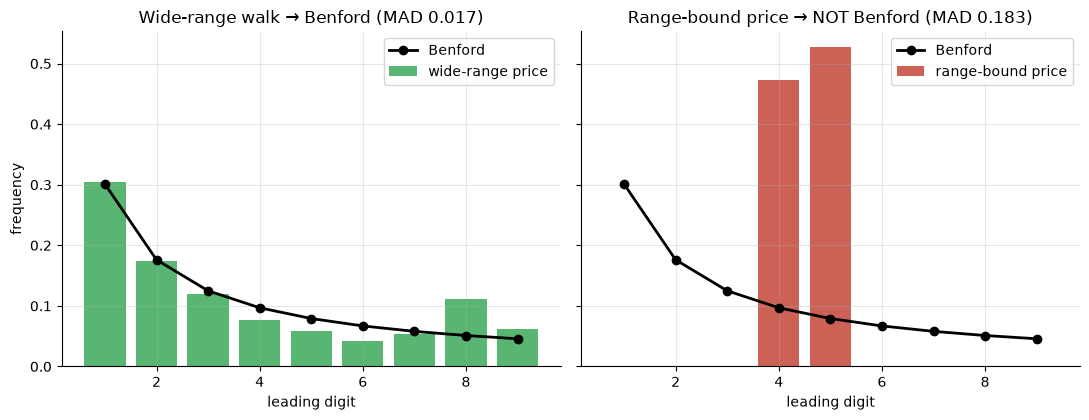

positive control spans 2.57 decades; anti-control spans 0.11 decades


In [2]:
sb, tb = data.synthetic_benford(); sn, tn = data.synthetic_nonbenford()
pmf = st.benford_pmf(); digs = np.arange(1, 10)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
a1.bar(digs, st.digit_frequencies(sb), color=GREEN, alpha=.8, label='wide-range price')
a1.plot(digs, pmf, 'ko-', lw=2, label='Benford')
a1.set_title(f'Wide-range walk → Benford (MAD {st.mad(sb):.3f})'); a1.legend()
a1.set_xlabel('leading digit'); a1.set_ylabel('frequency')
a2.bar(digs, st.digit_frequencies(sn), color=RED, alpha=.8, label='range-bound price')
a2.plot(digs, pmf, 'ko-', lw=2, label='Benford')
a2.set_title(f'Range-bound price → NOT Benford (MAD {st.mad(sn):.3f})'); a2.legend()
a2.set_xlabel('leading digit')
plt.tight_layout(); plt.show()
print(f'positive control spans {tb["log_range_decades"]:.2f} decades; '
      f'anti-control spans {tn["log_range_decades"]:.2f} decades')

The stick works: a price that ranges over decades is Benford; a price pinned to a band isn't (its digits are all 4s and 5s). **Benford is a statement about *range*.** Hold that thought.

**Now the real thing.** Here's a single ETF's actual prices vs Benford — and, beside it, the same ETF's *returns*:

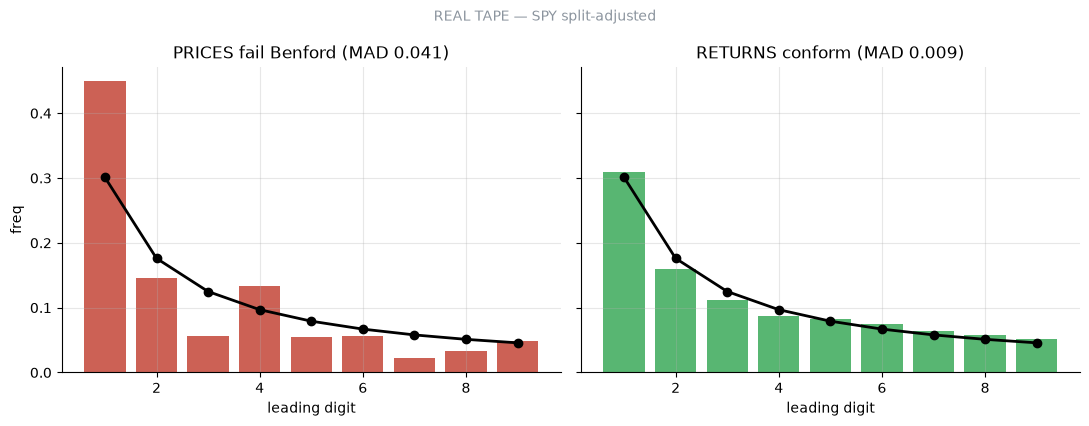

REAL TAPE — SPY split-adjusted


In [3]:
if HAVE_REAL:
    spy = data.load_real('SPY')
    px_freq = st.digit_frequencies(spy); px_mad = st.mad(spy)
    rt_freq = st.digit_frequencies(spy.pct_change().abs().dropna()); rt_mad = st.mad(spy.pct_change().abs().dropna())
    banner = 'REAL TAPE — SPY split-adjusted'
else:
    sb, _ = data.synthetic_benford(); nb_, _ = data.synthetic_nonbenford()
    px_freq = st.digit_frequencies(nb_); px_mad = st.mad(nb_)
    rt_freq = st.digit_frequencies(sb); rt_mad = st.mad(sb)
    banner = 'SYNTHETIC FALLBACK (no cache) — illustrative only'
pmf = st.benford_pmf(); digs = np.arange(1, 10)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
a1.bar(digs, px_freq, color=RED, alpha=.8); a1.plot(digs, pmf, 'ko-', lw=2)
a1.set_title(f'PRICES fail Benford (MAD {px_mad:.3f})'); a1.set_xlabel('leading digit'); a1.set_ylabel('freq')
a2.bar(digs, rt_freq, color=GREEN, alpha=.8); a2.plot(digs, pmf, 'ko-', lw=2)
a2.set_title(f'RETURNS conform (MAD {rt_mad:.3f})'); a2.set_xlabel('leading digit')
fig.suptitle(banner, fontsize=10, color=GREY); plt.tight_layout(); plt.show()
print(banner)

There's the punchline of the science: a **single** stock's *prices* do **not** obey Benford (SPY MAD **0.042**, far past the 0.015 nonconformity line) — it never spanned enough decades and dwelt in the 400s for years. The thing that *does* conform is **returns** (MAD **0.009**), because a daily move ranges from a whisper to a crash. The folklore has it backwards.

**So can you trade the 'deviation' anyway?** Short the most-deviant names, long the most-conforming, rebalanced monthly. On a panel of today's large caps it looks like a winner — until you notice *which* names are on the list:

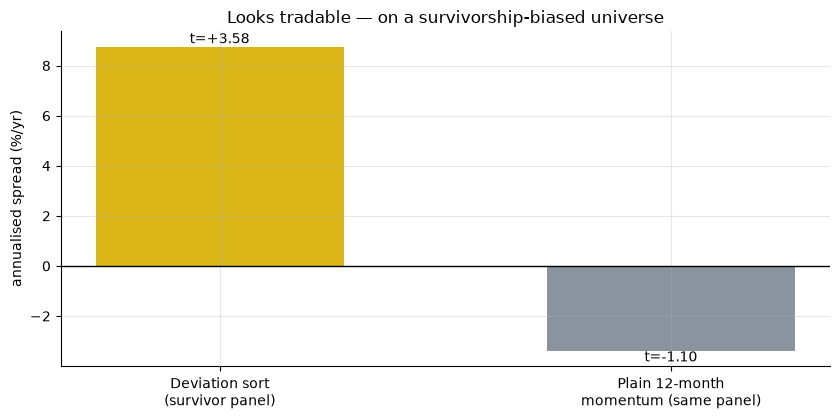

Deviation sort t=+3.58 — but the panel is CURRENT members (survivors).


In [4]:
labels = ['Deviation sort\n(survivor panel)', 'Plain 12-month\nmomentum (same panel)']
anns = [8.76, -3.39]
ts = [3.58, -1.10]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(labels, anns, color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised spread (%/yr)')
ax.set_title('Looks tradable — on a survivorship-biased universe')
for bar_, t_ in zip(b, ts):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()),
                ha='center', va='bottom' if bar_.get_height()>=0 else 'top')
plt.tight_layout(); plt.show()
print('Deviation sort t=+3.58 — but the panel is CURRENT members (survivors).')

The deviation sort prints **+8.8%/yr** at *t* = +3.6. But the universe is **current** large caps reconstructed after the fact — the textbook survivorship trap. A name flagged 'low-deviation / conforming' is, on this list, a name that *kept climbing across decades* — i.e. one that survived. We're not detecting integrity; we're re-discovering that survivors survived. (It isn't even plain momentum: vanilla 12-month momentum on the same panel is *negative*, -3.4%/yr.)

## 5 · The verdict

- **Signal — Mixed.** The deviation sort clears the bar (*t* ≈ +3.6) — but only on a survivorship-biased panel, and the premise ('prices obey Benford') is false for a single name. Significant-looking, uncertifiable.
- **Tradability — Mirage.** It needs a year of trailing prices *and* a universe you couldn't have known in real time. The deviation is a proxy for price-range and survival.
- **A forensic red-flag for trouble? — Not supported.** A single price's deviation is geometry (how narrow its range), not manipulation. The conforming quantity is *returns*, which carries no such 'trouble' reading at all.

## 6 · Could you actually trade it?

Set survivorship aside for a second and just ask about costs and capacity. The score needs a **252-day trailing window** before it says anything, the spread is modest, and the whole apparent edge evaporates the moment you swap the survivor list for a real, point-in-time universe (which we can't even build offline here — that's the tell). Costs are the *least* of its problems: even at 10 bps round-trip the survivor-panel number is still +6.6%/yr — but it's +6.6% of a mirage. There is nothing here to size.

## 7 · Going further 🚪

- **Where Benford is genuinely useful.** On *reported financials* (revenue, earnings) — its home turf — first-digit screens really do flag manipulation. That's the EDGAR data the desk caches; a fork could screen reported fundamentals, not prices.
- **Second-digit and last-digit tests.** Nigrini's full toolkit goes beyond the first digit; do they carry any more information on prices? (Bet: still no — same range problem.)
- **The honest control.** Re-run the sort on a *point-in-time* membership panel (through the survivorship opt-in guard) and watch the *t* collapse. That's the experiment that settles it.

*Think the digits hide a real signal? Fork this, build a point-in-time universe, and show the deviation sort surviving once the survivors stop choosing themselves.*